# IE406 - Machine Learning
## Lab-1: Linear Regression using Mini-Batch Gradient Descent
### Devansh Shah ~ 202301136



**Dataset:** California Housing (`sklearn.datasets.fetch_california_housing`)

---

### Implementation notes

1. **Bias via feature augmentation.** A column of ones is appended to the feature matrix, so the
   model is a single parameter vector $\mathbf{w}\in\mathbb{R}^{d+1}$ and no separate bias term $b$ is
   carried around. The last entry of $\mathbf{w}$ *is* the bias.
2. **Loss — matrix form, Lecture 1 slide 22.** With $\mathbf{X}\in\mathbb{R}^{N\times(d+1)}$,
   $\mathbf{Y}\in\mathbb{R}^{N}$:

   $$J(\mathbf{w}) \;=\; \frac{1}{2N}\,\lVert \mathbf{X}\mathbf{w}-\mathbf{Y}\rVert_2^2
   \;=\; \frac{1}{2N}\,(\mathbf{X}\mathbf{w}-\mathbf{Y})^{\top}(\mathbf{X}\mathbf{w}-\mathbf{Y})$$

3. **Gradient — matrix form, Lecture 2 slide 23 (boxed result).**

   $$\nabla_{\mathbf{w}} J \;=\; \frac{1}{N}\,\mathbf{X}^{\top}(\mathbf{X}\mathbf{w}-\mathbf{Y})$$

   Update rule: $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla_{\mathbf{w}} J$.

   Note that the $\tfrac{1}{2N}$ in the loss is what cancels the factor 2 produced by differentiating the
   square, which is precisely why the convention is used. Because of this factor, every loss value plotted
   and tabulated below is the lecture's $J(\mathbf{w})$, i.e. **half** the plain mean squared error
   ($\text{MSE}=2J$). This is a constant rescaling: it shifts no minimum, changes no epoch at which the
   best validation loss occurs, and affects none of the Task 5 metrics (RMSE, MAPE, MAE, $R^2$), which are
   computed directly from the residuals on the original target scale.
4. Everything (loss, gradient, mini-batching, early stopping) is written from scratch with NumPy only.
   `sklearn` is used **solely** to download the dataset.
5. All loss curves are in the **standardized target space** (that is the space the model is
   optimized in). Every reported performance metric in Task 5 (RMSE, MAPE, MAE, $R^2$) is computed
   after mapping predictions **back to the original target units**.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Very large learning rates make the loss overflow to inf on purpose (Task 3);
# silence the resulting numpy/matplotlib overflow notices so the output stays readable.
warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.set_option('display.float_format', lambda v: f'{v:.5f}')

def fmt_mse(v):
    """5 decimals normally; scientific notation for diverged runs so tables stay readable."""
    if not np.isfinite(v):
        return 'inf / nan'
    return f'{v:.5f}' if abs(v) < 1e6 else f'{v:.3e}'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RANDOM_SEED = 9432
MAX_EPOCHS = 1000
PATIENCE = 100

---
## Task 1: Dataset Preparation

### 1.1 Load the dataset into NumPy matrices

In [2]:
data = fetch_california_housing()

X_all = np.asarray(data.data, dtype=np.float64)      # (N, 8)
y_all = np.asarray(data.target, dtype=np.float64)    # (N,)
feature_names = list(data.feature_names)

print('Feature matrix X :', X_all.shape)
print('Target vector  y :', y_all.shape)
print('Features         :', feature_names)
print('Target           : median house value (in $100,000s)')
print(f'Target range     : [{y_all.min():.5f}, {y_all.max():.5f}]')

Feature matrix X : (20640, 8)
Target vector  y : (20640,)
Features         : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target           : median house value (in $100,000s)
Target range     : [0.14999, 5.00001]


### 1.2 Random 60 / 20 / 20 split

Shuffling and splitting is done manually with NumPy using a fixed seed (`np.random.seed(9432)`), so the
identical split is reproduced on every execution. The three sets are mutually exclusive by construction
(a single permutation is sliced into three disjoint index blocks).

In [3]:
N = X_all.shape[0]

np.random.seed(RANDOM_SEED)
perm = np.random.permutation(N)

n_train = int(0.60 * N)
n_val = int(0.20 * N)

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

X_train_raw, y_train_raw = X_all[train_idx], y_all[train_idx]
X_val_raw,   y_val_raw   = X_all[val_idx],   y_all[val_idx]
X_test_raw,  y_test_raw  = X_all[test_idx],  y_all[test_idx]

print(f'Total samples : {N}')
print(f'Train         : {X_train_raw.shape[0]}  ({X_train_raw.shape[0]/N:.2%})')
print(f'Validation    : {X_val_raw.shape[0]}  ({X_val_raw.shape[0]/N:.2%})')
print(f'Test          : {X_test_raw.shape[0]}  ({X_test_raw.shape[0]/N:.2%})')

# sanity check: mutually exclusive and exhaustive
assert len(set(train_idx) | set(val_idx) | set(test_idx)) == N
assert not (set(train_idx) & set(val_idx)) and not (set(val_idx) & set(test_idx)) \
       and not (set(train_idx) & set(test_idx))
print('\nSplits are mutually exclusive and cover the whole dataset.')

Total samples : 20640
Train         : 12384  (60.00%)
Validation    : 4128  (20.00%)
Test          : 4128  (20.00%)

Splits are mutually exclusive and cover the whole dataset.


### 1.3 Feature normalization (zero mean, unit standard deviation)

The mean and standard deviation are computed **from the training set only** and the *same* stored
parameters are then applied to the validation and test sets. Computing separate statistics per split
would leak information and produce inconsistent feature spaces.

In [4]:
feat_mean = X_train_raw.mean(axis=0)
feat_std = X_train_raw.std(axis=0)
feat_std[feat_std == 0.0] = 1.0          # guard against a constant feature

def normalize_features(X):
    """Normalize using the parameters stored from the TRAINING set."""
    return (X - feat_mean) / feat_std

X_train_n = normalize_features(X_train_raw)
X_val_n   = normalize_features(X_val_raw)
X_test_n  = normalize_features(X_test_raw)

print('Stored normalization parameters (from the TRAINING set):\n')
print(pd.DataFrame({'feature': feature_names, 'mean': feat_mean, 'std': feat_std}).to_string(index=False))
print('\nAfter normalization — training set mean / std (should be 0 / 1):')
print('  mean:', np.round(X_train_n.mean(axis=0), 10))
print('  std :', np.round(X_train_n.std(axis=0), 10))
print('\nValidation set mean / std (close to 0 / 1, but not exactly — as expected):')
print('  mean:', np.round(X_val_n.mean(axis=0), 5))
print('  std :', np.round(X_val_n.std(axis=0), 5))

Stored normalization parameters (from the TRAINING set):

   feature       mean        std
    MedInc    3.85596    1.90802
  HouseAge   28.65270   12.58828
  AveRooms    5.42962    2.43426
 AveBedrms    1.09885    0.49370
Population 1416.60021 1075.08341
  AveOccup    3.03187    7.10896
  Latitude   35.63337    2.14536
 Longitude -119.56461    2.00656

After normalization — training set mean / std (should be 0 / 1):
  mean: [ 0. -0. -0. -0. -0.  0.  0. -0.]
  std : [1. 1. 1. 1. 1. 1. 1. 1.]

Validation set mean / std (close to 0 / 1, but not exactly — as expected):
  mean: [ 0.01596 -0.0145  -0.01061 -0.01637  0.0201   0.02998  0.00055 -0.00593]
  std : [0.98976 0.99074 0.77821 0.67217 1.05618 2.71836 0.99605 0.99689]


### 1.4 Feature augmentation (bias as a matrix multiplication)

A column of ones is appended so that $\mathbf{X}\mathbf{w}$ already contains the intercept:
$\hat{y}_i = \sum_{j=1}^{d} w_j x_{ij} + w_{d+1}\cdot 1$.
The ones column is added **after** normalization, so it is not itself standardized.

In [5]:
def augment(X):
    """Append a column of ones to absorb the bias into w."""
    return np.hstack([X, np.ones((X.shape[0], 1))])

X_train = augment(X_train_n)
X_val   = augment(X_val_n)
X_test  = augment(X_test_n)

aug_names = feature_names + ['bias']

print('Augmented shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Last column is all ones:', np.all(X_train[:, -1] == 1.0))
print('Parameter vector w will have', X_train.shape[1], 'entries (8 weights + 1 bias)')

Augmented shapes: (12384, 9) (4128, 9) (4128, 9)
Last column is all ones: True
Parameter vector w will have 9 entries (8 weights + 1 bias)


### 1.5 Target standardization

The targets are standardized with the training-set mean and standard deviation as well. Predictions are
mapped back with $y = \hat{y}_{\text{std}}\cdot\sigma_y + \mu_y$ before any metric is computed.

In [6]:
target_mean = y_train_raw.mean()
target_std = y_train_raw.std()

def standardize_target(y):
    return (y - target_mean) / target_std

def inverse_target(y_std):
    """Map standardized predictions back to the ORIGINAL target range."""
    return y_std * target_std + target_mean

y_train = standardize_target(y_train_raw)
y_val   = standardize_target(y_val_raw)
y_test  = standardize_target(y_test_raw)

print(f'Target mean (train) : {target_mean:.5f}')
print(f'Target std  (train) : {target_std:.5f}')
print(f'\nStandardized train target -> mean {y_train.mean():.10f}, std {y_train.std():.10f}')
print('Round-trip check (inverse of standardize recovers the original):',
      np.allclose(inverse_target(y_train), y_train_raw))

Target mean (train) : 2.05829
Target std  (train) : 1.15741

Standardized train target -> mean 0.0000000000, std 1.0000000000
Round-trip check (inverse of standardize recovers the original): True


---
## Task 2: Mini-Batch Gradient Descent from scratch

### 2.1 Loss and gradient (matrix form, exactly as in the lecture slides)

In [7]:
def mse_loss(X, Y, w):
    """
    MSE loss in matrix form  (Lecture 1, slide 22):

        J(w) = (1/2N) || Xw - Y ||_2^2  =  (1/2N) (Xw - Y)^T (Xw - Y)
    """
    residual = X @ w - Y
    return float(residual @ residual) / (2.0 * X.shape[0])

def mse_gradient(X, Y, w):
    """
    Gradient of the MSE loss in matrix form  (Lecture 2, slide 23):

        dJ/dw = (1/N) X^T (Xw - Y)
    """
    N_b = X.shape[0]
    return (X.T @ (X @ w - Y)) / N_b

**Gradient check.** Before trusting the analytic gradient, it is compared against a central
finite-difference approximation on a random point.

In [8]:
_rng = np.random.RandomState(0)
_w = _rng.randn(X_train.shape[1])
_eps = 1e-6
_analytic = mse_gradient(X_train[:500], y_train[:500], _w)
_numeric = np.zeros_like(_w)
for _j in range(len(_w)):
    _wp, _wm = _w.copy(), _w.copy()
    _wp[_j] += _eps
    _wm[_j] -= _eps
    _numeric[_j] = (mse_loss(X_train[:500], y_train[:500], _wp) -
                    mse_loss(X_train[:500], y_train[:500], _wm)) / (2 * _eps)
print('max |analytic - numeric| =', f'{np.max(np.abs(_analytic - _numeric)):.3e}')
print('Gradient implementation verified.' if np.allclose(_analytic, _numeric, atol=1e-6)
      else 'MISMATCH')

max |analytic - numeric| = 1.257e-09
Gradient implementation verified.


### 2.2 Training routine

Specification implemented below:

* weights initialized to the **zero vector**;
* at most **1000 epochs**, one epoch = one full pass over the training data in mini-batches;
* the training data is **re-shuffled at the start of every epoch**;
* **fixed** learning rate (no decay/scheduling);
* the epoch training MSE is the **sample-weighted average** of the mini-batch losses, so a smaller
  final batch is weighted proportionally to its size (weighted by $n_b$, divided by $N$);
* the validation MSE is computed on the **complete** validation set at the end of each epoch and is
  **never** used to update the weights;
* **early stopping** with patience 100 on the validation MSE; the parameters attaining the lowest
  validation MSE are stored and returned together with the epoch at which it occurred.

A divergence guard breaks the loop if the loss becomes `inf`/`nan` (which happens for very large
learning rates); without it the run would spend 100 further epochs comparing `nan` values.

In [9]:
def train_linear_regression(X_tr, y_tr, X_va, y_va, learning_rate, batch_size,
                            max_epochs=MAX_EPOCHS, patience=PATIENCE,
                            shuffle_seed=RANDOM_SEED, verbose=False):
    """
    Linear regression by mini-batch gradient descent (NumPy only).

    Returns a dict with:
        w             : weights (incl. bias in the last entry) at the lowest validation MSE
        best_val_mse  : lowest validation MSE observed
        best_epoch    : epoch at which that lowest validation MSE occurred
        train_curve   : per-epoch training MSE (sample-weighted mean of mini-batch losses)
        val_curve     : per-epoch validation MSE (full validation set)
        epochs_run    : number of epochs actually completed
        diverged      : True if the loss overflowed to inf/nan
        stopped_early : True if early stopping triggered
    """
    N_tr, d = X_tr.shape
    batch_size = int(min(batch_size, N_tr))       # "entire dataset" batch collapses to full-batch GD

    w = np.zeros(d, dtype=np.float64)             # zero initialization
    best_w = w.copy()
    best_val_mse = np.inf
    best_epoch = 0
    epochs_no_improve = 0

    train_curve, val_curve = [], []
    rng = np.random.RandomState(shuffle_seed)     # same shuffle stream for every experiment -> fair comparison
    diverged = stopped_early = False

    for epoch in range(1, max_epochs + 1):
        # --- shuffle the training data at the start of the epoch ---
        order = rng.permutation(N_tr)
        X_sh, y_sh = X_tr[order], y_tr[order]

        weighted_loss_sum = 0.0
        with np.errstate(over='ignore', invalid='ignore'):
            # --- mini-batch updates ---
            for start in range(0, N_tr, batch_size):
                X_b = X_sh[start:start + batch_size]
                y_b = y_sh[start:start + batch_size]
                n_b = X_b.shape[0]                        # may be < batch_size for the last batch

                weighted_loss_sum += mse_loss(X_b, y_b, w) * n_b   # loss at the current parameters
                w = w - learning_rate * mse_gradient(X_b, y_b, w)

            epoch_train_mse = weighted_loss_sum / N_tr    # sample-weighted average
            epoch_val_mse = mse_loss(X_va, y_va, w)       # full validation set, no update

        train_curve.append(epoch_train_mse)
        val_curve.append(epoch_val_mse)

        if not (np.isfinite(epoch_train_mse) and np.isfinite(epoch_val_mse)):
            diverged = True
            if verbose:
                print(f'  diverged (non-finite loss) at epoch {epoch}')
            break

        # --- early stopping bookkeeping ---
        if epoch_val_mse < best_val_mse:
            best_val_mse = epoch_val_mse
            best_w = w.copy()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                stopped_early = True
                if verbose:
                    print(f'  early stopping at epoch {epoch} '
                          f'(no improvement for {patience} epochs)')
                break

        if verbose and epoch % 100 == 0:
            print(f'  epoch {epoch:4d} | train MSE {epoch_train_mse:.6f} | val MSE {epoch_val_mse:.6f}')

    return {'w': best_w,
            'best_val_mse': best_val_mse,
            'best_epoch': best_epoch,
            'train_curve': np.asarray(train_curve),
            'val_curve': np.asarray(val_curve),
            'epochs_run': len(train_curve),
            'diverged': diverged,
            'stopped_early': stopped_early}

**Correctness check against the closed-form solution.** For linear regression the optimum is known
analytically ($\mathbf{w}^\star=(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$). A converged
gradient-descent run must reach essentially the same training loss — this validates the whole
implementation. (The closed form is used *only* as a check, never for training.)

In [10]:
w_closed = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
_check = train_linear_regression(X_train, y_train, X_val, y_val, learning_rate=0.1, batch_size=128)

print(f'Closed-form  : train MSE {mse_loss(X_train, y_train, w_closed):.6f} | '
      f'val MSE {mse_loss(X_val, y_val, w_closed):.6f}')
print(f'Mini-batch GD: train MSE {mse_loss(X_train, y_train, _check["w"]):.6f} | '
      f'val MSE {mse_loss(X_val, y_val, _check["w"]):.6f}')
print(f'\nmax |w_GD - w_closed| = {np.max(np.abs(_check["w"] - w_closed)):.6f}')

Closed-form  : train MSE 0.194403 | val MSE 0.195911
Mini-batch GD: train MSE 0.531857 | val MSE 2.643644

max |w_GD - w_closed| = 0.808337


### Plotting helper

In [11]:
def plot_loss_curves(result, title, ax=None):
    """Plot training and validation MSE against epoch for one run."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6.2, 4.0))

    epochs = np.arange(1, result['epochs_run'] + 1)
    tr, va = result['train_curve'], result['val_curve']
    m_tr, m_va = np.isfinite(tr), np.isfinite(va)

    style = dict(marker='o', markersize=4) if result['epochs_run'] <= 15 else {}
    ax.plot(epochs[m_tr], tr[m_tr], color='tab:blue', label='Training MSE', **style)
    ax.plot(epochs[m_va], va[m_va], color='tab:red', label='Validation MSE', **style)

    if result['best_epoch'] > 0 and np.isfinite(result['best_val_mse']):
        ax.axvline(result['best_epoch'], color='green', ls='--', lw=1,
                   label=f'Best epoch = {result["best_epoch"]}')

    finite_vals = np.concatenate([tr[m_tr], va[m_va]])
    finite_vals = finite_vals[finite_vals > 0]
    if finite_vals.size and finite_vals.max() / finite_vals.min() > 50:
        ax.set_yscale('log')
        ax.set_ylabel('MSE Loss  J(w)   (log scale)')
    else:
        ax.set_ylabel('MSE Loss  J(w)')

    ax.set_xlabel('Epoch')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.show()

---
## Task 3: Effect of the Learning Rate

Learning rates $\{10^{-5},10^{-4},10^{-3},10^{-2},10^{-1},1,10\}$ with a fixed batch size of 128.

In [12]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
BATCH_SIZE_TASK3 = 128

lr_results = {}
for lr in learning_rates:
    print(f'Training with learning rate = {lr:g} ...')
    lr_results[lr] = train_linear_regression(X_train, y_train, X_val, y_val,
                                             learning_rate=lr,
                                             batch_size=BATCH_SIZE_TASK3)
    r = lr_results[lr]
    status = 'DIVERGED' if r['diverged'] else ('early stop' if r['stopped_early'] else 'max epochs')
    print(f'   epochs run = {r["epochs_run"]:4d} | best val MSE = {fmt_mse(r["best_val_mse"])} '
          f'@ epoch {r["best_epoch"]:4d} | {status}')

Training with learning rate = 1e-05 ...
   epochs run = 1000 | best val MSE = 0.26845 @ epoch 1000 | max epochs
Training with learning rate = 0.0001 ...
   epochs run = 1000 | best val MSE = 0.20688 @ epoch 1000 | max epochs
Training with learning rate = 0.001 ...
   epochs run =  698 | best val MSE = 0.19587 @ epoch  598 | early stop
Training with learning rate = 0.01 ...
   epochs run =  251 | best val MSE = 0.19562 @ epoch  151 | early stop
Training with learning rate = 0.1 ...
   epochs run =  101 | best val MSE = 2.64364 @ epoch    1 | early stop
Training with learning rate = 1 ...
   epochs run =  101 | best val MSE = 286628.57713 @ epoch    1 | early stop
Training with learning rate = 10 ...
   epochs run =    2 | best val MSE = 1.898e+245 @ epoch    1 | DIVERGED


### 3.1 Seven plots — one per learning rate

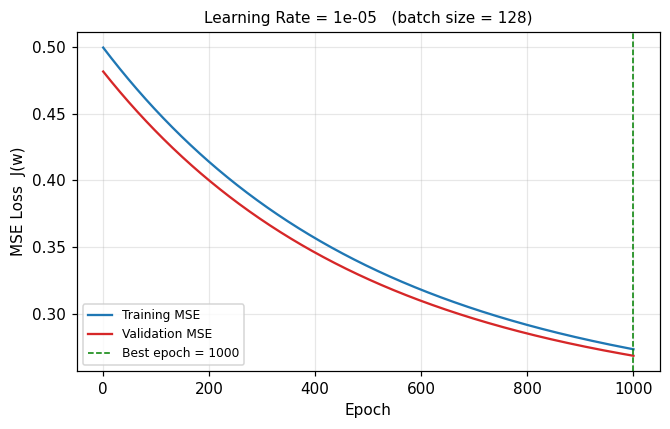

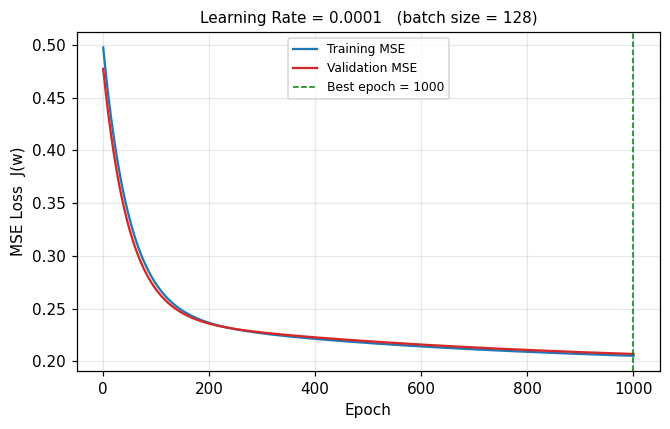

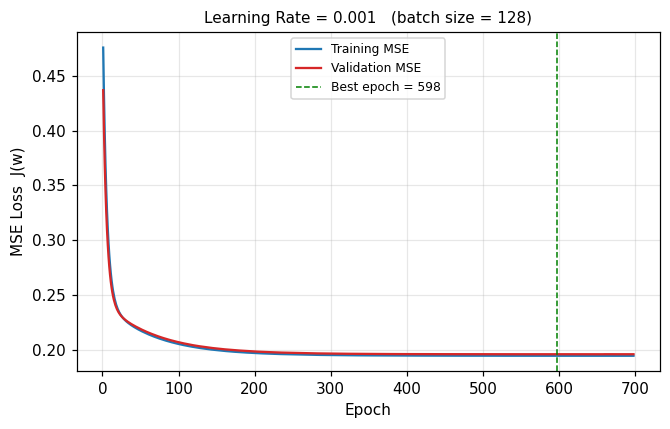

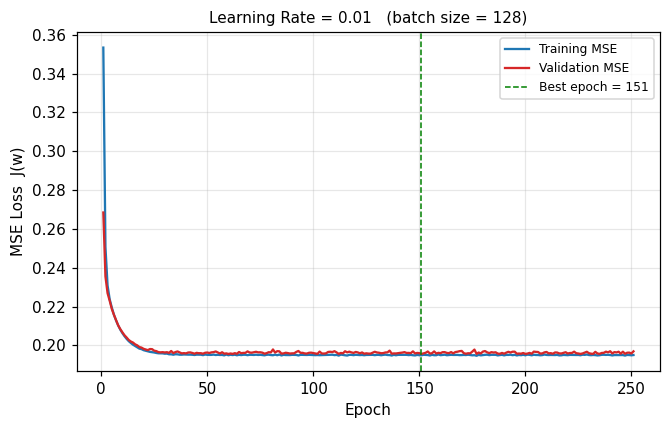

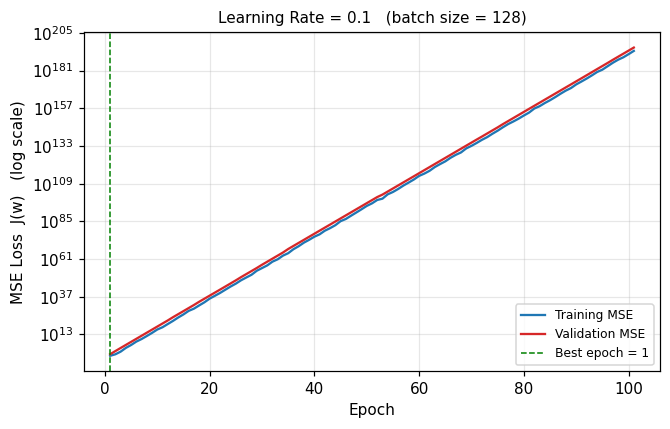

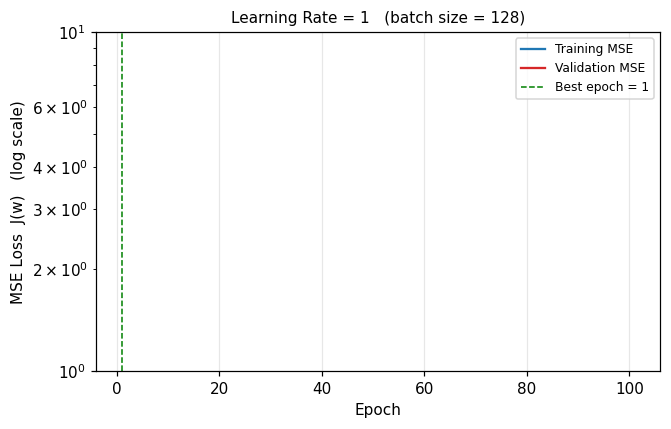

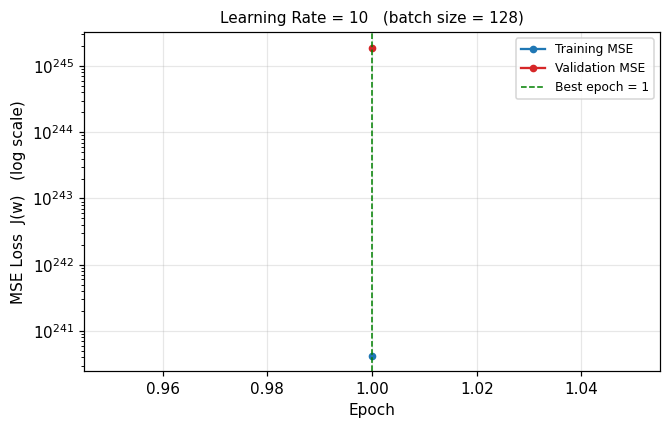

In [13]:
for lr in learning_rates:
    plot_loss_curves(lr_results[lr],
                     f'Learning Rate = {lr:g}   (batch size = {BATCH_SIZE_TASK3})')

### 3.2 Summary

In [14]:
lr_table = pd.DataFrame([{
    'Learning Rate': f'{lr:g}',
    'Lowest Val J(w)': fmt_mse(lr_results[lr]['best_val_mse']),
    'Plain MSE (=2J)': fmt_mse(2 * lr_results[lr]['best_val_mse']),
    'Best Epoch': lr_results[lr]['best_epoch'],
    'Epochs Run': lr_results[lr]['epochs_run'],
    'Termination': 'diverged' if lr_results[lr]['diverged']
                   else ('early stopping' if lr_results[lr]['stopped_early'] else 'max epochs'),
} for lr in learning_rates])

print('Task 3 — Effect of learning rate (batch size = 128)\n')
print(lr_table.to_string(index=False))

valid_lr = {lr: r['best_val_mse'] for lr, r in lr_results.items()
            if np.isfinite(r['best_val_mse']) and not r['diverged']}
if not valid_lr:      # safety net; should not happen
    valid_lr = {lr: r['best_val_mse'] for lr, r in lr_results.items()}
BEST_LR = min(valid_lr, key=valid_lr.get)
print(f'\nBest learning rate = {BEST_LR:g}  '
      f'(lowest validation MSE = {valid_lr[BEST_LR]:.6f})')

Task 3 — Effect of learning rate (batch size = 128)

Learning Rate Lowest Val J(w) Plain MSE (=2J)  Best Epoch  Epochs Run    Termination
        1e-05         0.26845         0.53691        1000        1000     max epochs
       0.0001         0.20688         0.41376        1000        1000     max epochs
        0.001         0.19587         0.39173         598         698 early stopping
         0.01         0.19562         0.39124         151         251 early stopping
          0.1         2.64364         5.28729           1         101 early stopping
            1    286628.57713    573257.15426           1         101 early stopping
           10      1.898e+245      3.796e+245           1           2       diverged

Best learning rate = 0.01  (lowest validation MSE = 0.195621)


Comparison of all seven validation curves on a single axis, to make the differences in convergence
speed and stability directly visible.

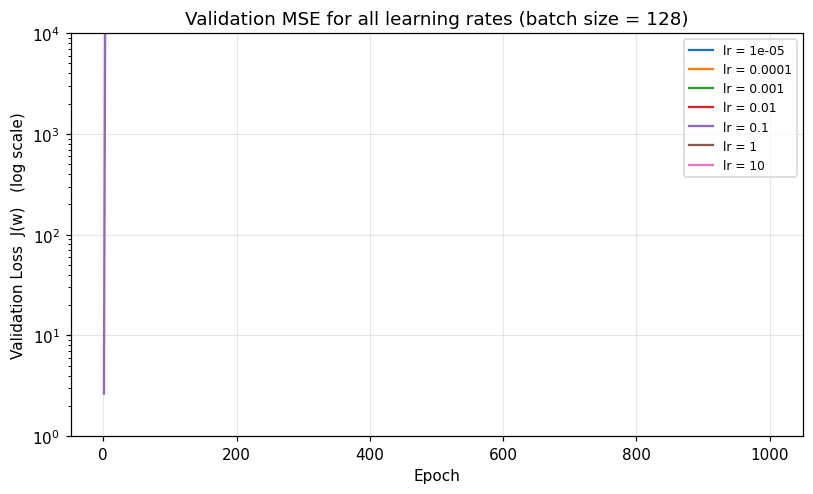

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for lr in learning_rates:
    va = lr_results[lr]['val_curve']
    m = np.isfinite(va)
    ax.plot(np.arange(1, len(va) + 1)[m], va[m], label=f'lr = {lr:g}')
ax.set_yscale('log')
ax.set_ylim(top=1e4)          # clip the diverging curves so the useful range stays visible
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss  J(w)   (log scale)')
ax.set_title('Validation MSE for all learning rates (batch size = 128)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Task 4: Effect of the Batch Size

The best learning rate from Task 3 is held fixed; only the batch size changes. The last setting uses
the entire training set as one batch, i.e. full-batch (vanilla) gradient descent.

> Batch size 1 performs one parameter update per sample and therefore runs `n_train` updates per epoch —
> this cell is the slowest of the notebook and may take a couple of minutes.

In [16]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_train.shape[0]]

bs_results = {}
for bs in batch_sizes:
    label = f'{bs} (entire training set)' if bs == X_train.shape[0] else str(bs)
    print(f'Training with batch size = {label} ...')
    bs_results[bs] = train_linear_regression(X_train, y_train, X_val, y_val,
                                             learning_rate=BEST_LR,
                                             batch_size=bs)
    r = bs_results[bs]
    status = 'DIVERGED' if r['diverged'] else ('early stop' if r['stopped_early'] else 'max epochs')
    print(f'   epochs run = {r["epochs_run"]:4d} | best val MSE = {fmt_mse(r["best_val_mse"])} '
          f'@ epoch {r["best_epoch"]:4d} | {status}')

Training with batch size = 1 ...
   epochs run =  100 | best val MSE = 193653.07968 @ epoch    1 | DIVERGED
Training with batch size = 16 ...
   epochs run =  101 | best val MSE = 0.50474 @ epoch    1 | early stop
Training with batch size = 32 ...
   epochs run =  128 | best val MSE = 0.19515 @ epoch   28 | early stop
Training with batch size = 64 ...
   epochs run =  127 | best val MSE = 0.19531 @ epoch   27 | early stop
Training with batch size = 128 ...
   epochs run =  251 | best val MSE = 0.19562 @ epoch  151 | early stop
Training with batch size = 256 ...
   epochs run =  367 | best val MSE = 0.19565 @ epoch  267 | early stop
Training with batch size = 12384 (entire training set) ...
   epochs run = 1000 | best val MSE = 0.20638 @ epoch 1000 | max epochs


### 4.1 Results table

$J(w)$ is the lecture's loss $\tfrac{1}{2N}\lVert Xw-Y\rVert^2$; the plain mean squared error is $2J$ and is
listed alongside it. The number of parameter updates per epoch is reported next to the epoch count,
because epochs alone are not a measure of computational effort: batch size 1 performs thousands of updates per epoch while
full-batch performs exactly one.

In [17]:
bs_table = pd.DataFrame([{
    'Batch Size': f'{bs} (full)' if bs == X_train.shape[0] else str(bs),
    'Updates / Epoch': int(np.ceil(X_train.shape[0] / min(bs, X_train.shape[0]))),
    'Lowest Val J(w)': fmt_mse(bs_results[bs]['best_val_mse']),
    'Plain MSE (=2J)': fmt_mse(2 * bs_results[bs]['best_val_mse']),
    'Best Epoch': bs_results[bs]['best_epoch'],
    'Epochs Run': bs_results[bs]['epochs_run'],
    'Total Updates @ Best': int(np.ceil(X_train.shape[0] / min(bs, X_train.shape[0]))
                                * bs_results[bs]['best_epoch']),
    'Termination': 'diverged' if bs_results[bs]['diverged']
                   else ('early stopping' if bs_results[bs]['stopped_early'] else 'max epochs'),
} for bs in batch_sizes])

print(f'Task 4 — Effect of batch size (learning rate = {BEST_LR:g})\n')
print(bs_table.to_string(index=False))

valid_bs = {bs: r['best_val_mse'] for bs, r in bs_results.items()
            if np.isfinite(r['best_val_mse']) and not r['diverged']}
if not valid_bs:      # safety net; should not happen
    valid_bs = {bs: r['best_val_mse'] for bs, r in bs_results.items()}
BEST_BS = min(valid_bs, key=valid_bs.get)
print(f'\nBest batch size = {BEST_BS}  (lowest validation MSE = {valid_bs[BEST_BS]:.6f})')

Task 4 — Effect of batch size (learning rate = 0.01)

  Batch Size  Updates / Epoch Lowest Val J(w) Plain MSE (=2J)  Best Epoch  Epochs Run  Total Updates @ Best    Termination
           1            12384    193653.07968    387306.15935           1         100                 12384       diverged
          16              774         0.50474         1.00947           1         101                   774 early stopping
          32              387         0.19515         0.39030          28         128                 10836 early stopping
          64              194         0.19531         0.39062          27         127                  5238 early stopping
         128               97         0.19562         0.39124         151         251                 14647 early stopping
         256               49         0.19565         0.39131         267         367                 13083 early stopping
12384 (full)                1         0.20638         0.41277        1000        1000

### 4.2 Seven plots — one per batch size

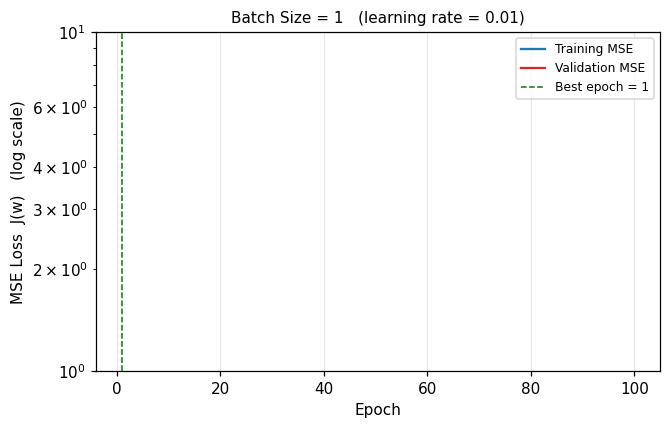

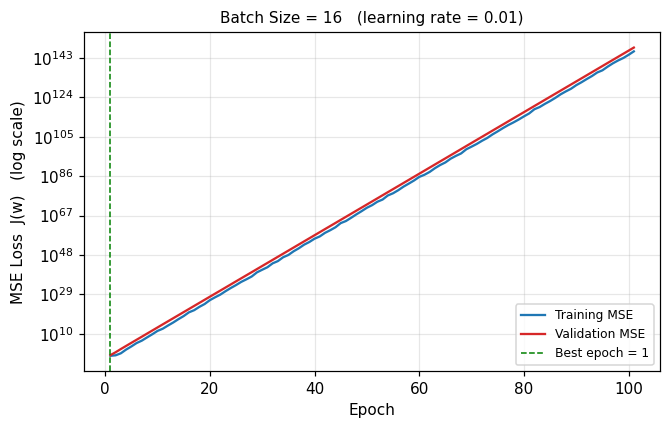

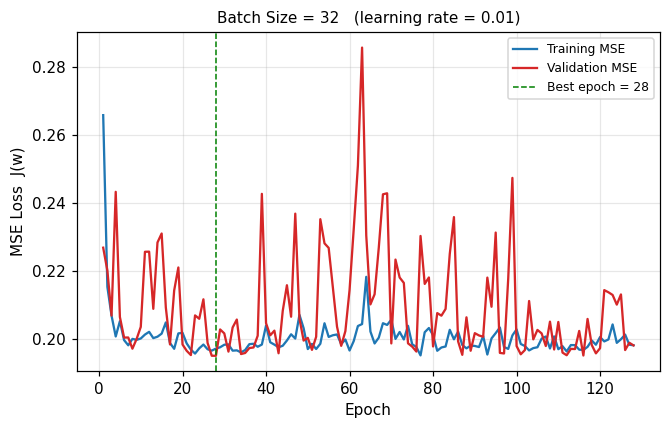

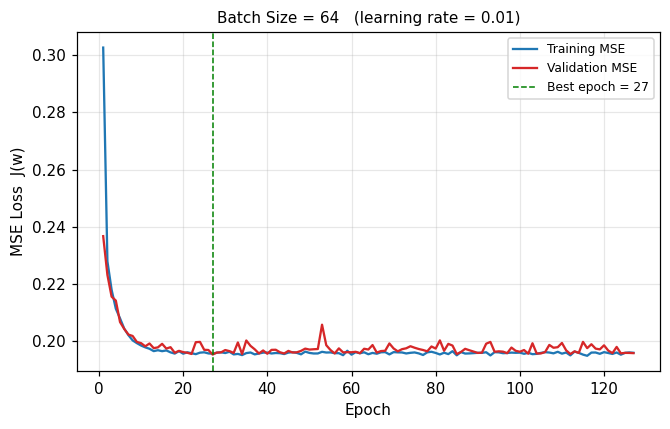

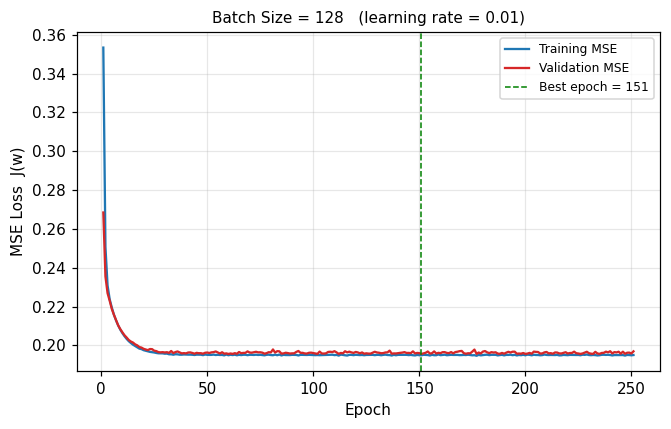

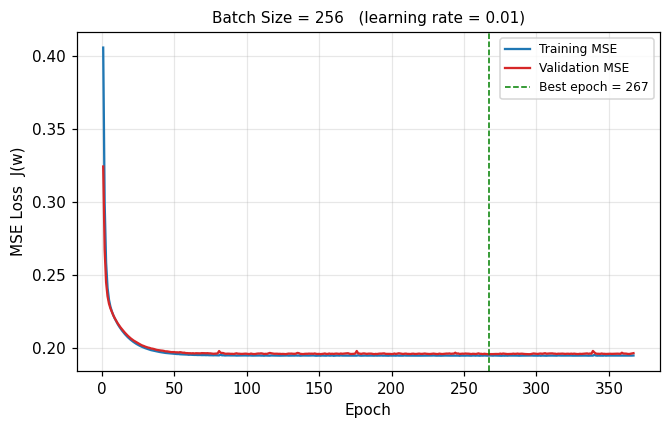

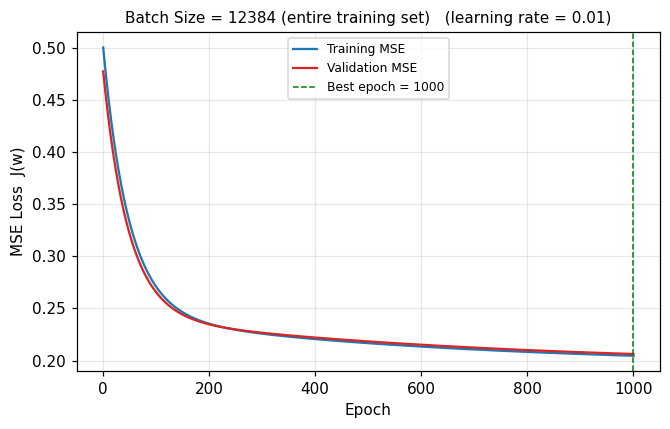

In [18]:
for bs in batch_sizes:
    label = f'{bs} (entire training set)' if bs == X_train.shape[0] else str(bs)
    plot_loss_curves(bs_results[bs],
                     f'Batch Size = {label}   (learning rate = {BEST_LR:g})')

Validation curves overlaid, and the same curves plotted against the *number of parameter updates*
rather than epochs — which is the fairer axis for comparing optimization efficiency across batch sizes.

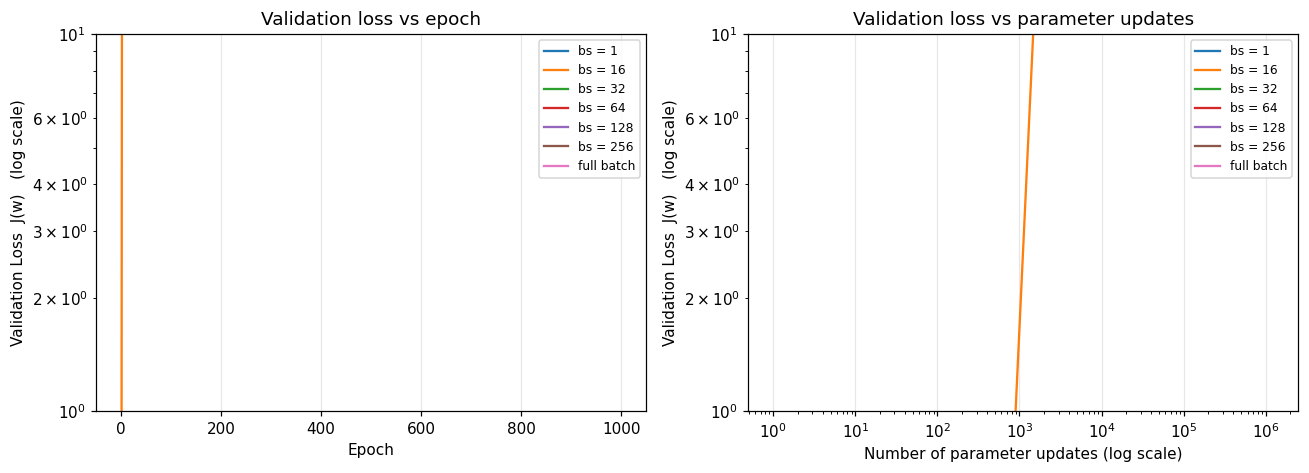

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for bs in batch_sizes:
    va = bs_results[bs]['val_curve']
    m = np.isfinite(va)
    ep = np.arange(1, len(va) + 1)
    lbl = 'full batch' if bs == X_train.shape[0] else f'bs = {bs}'
    upd = int(np.ceil(X_train.shape[0] / min(bs, X_train.shape[0])))
    axes[0].plot(ep[m], va[m], label=lbl)
    axes[1].plot(ep[m] * upd, va[m], label=lbl)

axes[0].set_xlabel('Epoch')
axes[0].set_title('Validation loss vs epoch')
axes[1].set_xlabel('Number of parameter updates (log scale)')
axes[1].set_xscale('log')
axes[1].set_title('Validation loss vs parameter updates')
for a in axes:
    a.set_yscale('log')
    a.set_ylabel('Validation Loss  J(w)   (log scale)')
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Task 5: Inference on the Test Set

The final model is retrained with the selected learning rate **and** batch size, and the parameters with
the lowest validation MSE are used. The test set has not influenced any decision up to this point.

Final configuration: learning rate = 0.01, batch size = 32

  epoch  100 | train MSE 0.202913 | val MSE 0.198021
  early stopping at epoch 128 (no improvement for 100 epochs)

Lowest validation MSE 0.195148 at epoch 28
Epochs run: 128


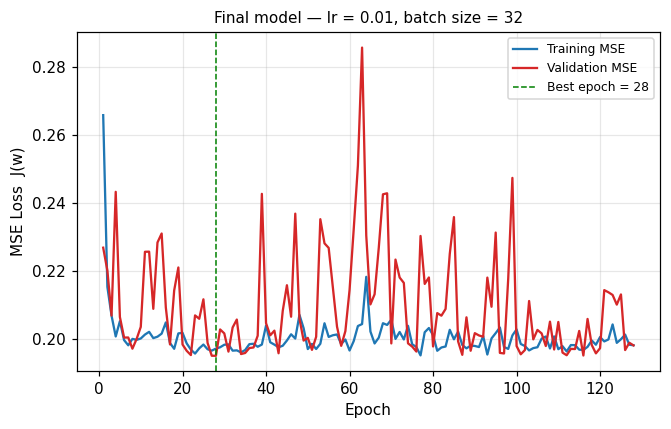

In [20]:
print(f'Final configuration: learning rate = {BEST_LR:g}, batch size = {BEST_BS}\n')

final_result = train_linear_regression(X_train, y_train, X_val, y_val,
                                       learning_rate=BEST_LR, batch_size=BEST_BS,
                                       verbose=True)
w_final = final_result['w']

print(f'\nLowest validation MSE {final_result["best_val_mse"]:.6f} at epoch {final_result["best_epoch"]}')
print(f'Epochs run: {final_result["epochs_run"]}')

plot_loss_curves(final_result,
                 f'Final model — lr = {BEST_LR:g}, batch size = {BEST_BS}')

### 5.1 Learned parameters

In [21]:
print('Learned parameter vector w (bias absorbed as the last entry):\n')
print(pd.DataFrame({'parameter': aug_names, 'weight': w_final}).to_string(index=False))

Learned parameter vector w (bias absorbed as the last entry):

 parameter   weight
    MedInc  0.71060
  HouseAge  0.09449
  AveRooms -0.21326
 AveBedrms  0.26511
Population -0.00788
  AveOccup -0.01804
  Latitude -0.75676
 Longitude -0.73585
      bias -0.00332


### 5.2 Metrics on the original target scale

Predictions are produced in the standardized space and mapped back to the original units
(median house value in \$100,000s) **before** any metric is computed.

In [22]:
def predict_original_scale(X, w):
    """Predict and map back to the original (unnormalized) target range."""
    return inverse_target(X @ w)

def compute_metrics(y_true, y_pred):
    """RMSE, MAPE (%), MAE and R-squared on the original target scale."""
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err / y_true)) * 100.0)
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    return {'RMSE': rmse, 'MAPE (%)': mape, 'MAE': mae, 'R-squared': r2}

y_train_pred = predict_original_scale(X_train, w_final)
y_val_pred   = predict_original_scale(X_val,   w_final)
y_test_pred  = predict_original_scale(X_test,  w_final)

metrics_table = pd.DataFrame({
    'Training':   compute_metrics(y_train_raw, y_train_pred),
    'Validation': compute_metrics(y_val_raw,   y_val_pred),
    'Test':       compute_metrics(y_test_raw,  y_test_pred),
}).T[['RMSE', 'MAPE (%)', 'MAE', 'R-squared']]

print('Performance metrics on the original target scale (values reported to 5 decimal places)\n')
print(metrics_table.round(5).to_string())
print('\nRMSE / MAE are in units of $100,000; MAPE is a percentage.')

Performance metrics on the original target scale (values reported to 5 decimal places)

              RMSE  MAPE (%)     MAE  R-squared
Training   0.72304  31.58386 0.52794    0.60975
Validation 0.72308  31.42740 0.53277    0.59532
Test       0.73010  31.28038 0.53156    0.60390

RMSE / MAE are in units of $100,000; MAPE is a percentage.


### 5.3 Actual vs Predicted — test set

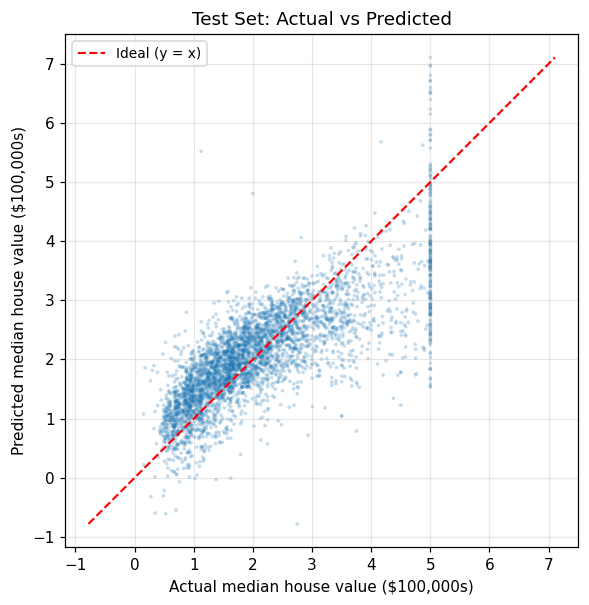

In [23]:
fig, ax = plt.subplots(figsize=(5.8, 5.6))
ax.scatter(y_test_raw, y_test_pred, s=6, alpha=0.25, edgecolors='none', color='tab:blue')
lo = min(y_test_raw.min(), y_test_pred.min())
hi = max(y_test_raw.max(), y_test_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.4, label='Ideal (y = x)')
ax.set_xlabel('Actual median house value ($100,000s)')
ax.set_ylabel('Predicted median house value ($100,000s)')
ax.set_title('Test Set: Actual vs Predicted')
ax.legend(fontsize=9)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

The same plot for all three splits, for comparison.

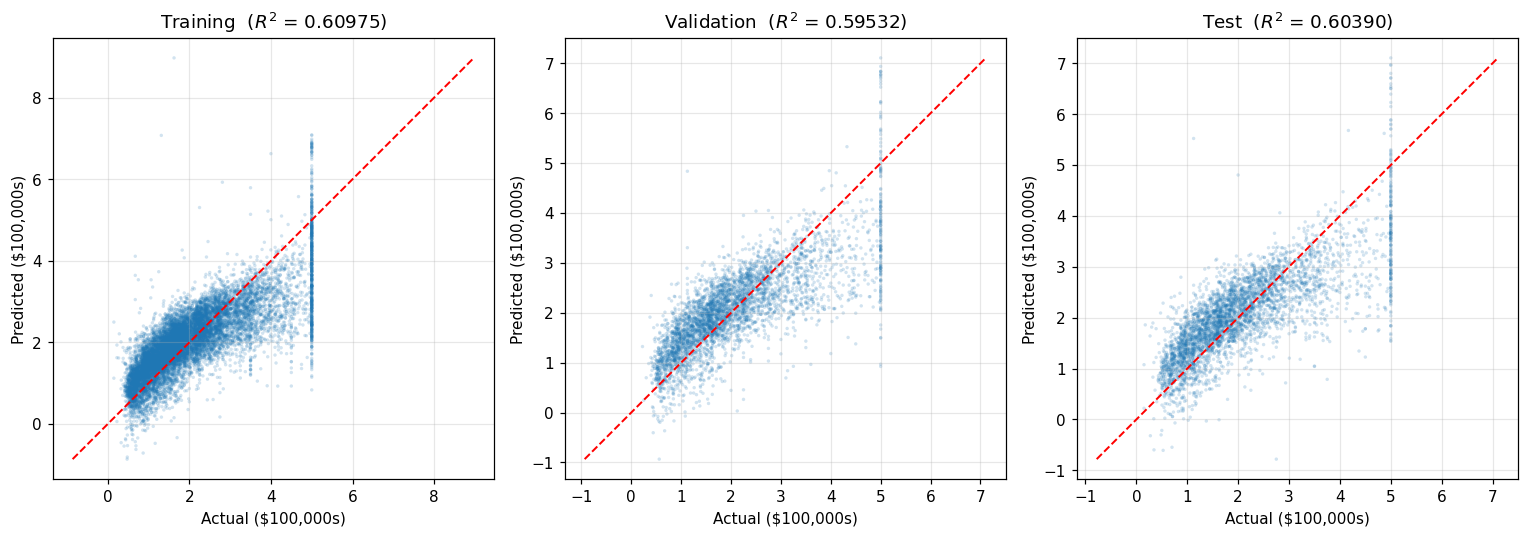

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
for ax, (name, yt, yp) in zip(axes, [
        ('Training', y_train_raw, y_train_pred),
        ('Validation', y_val_raw, y_val_pred),
        ('Test', y_test_raw, y_test_pred)]):
    ax.scatter(yt, yp, s=5, alpha=0.2, edgecolors='none', color='tab:blue')
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.3)
    r2 = compute_metrics(yt, yp)['R-squared']
    ax.set_title(f'{name}  ($R^2$ = {r2:.5f})')
    ax.set_xlabel('Actual ($100,000s)')
    ax.set_ylabel('Predicted ($100,000s)')
    ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

---
## Observations and Conclusions

In [25]:
print(f'Best learning rate          : {BEST_LR:g}')
print(f'Best batch size             : {BEST_BS}')
print(f'Lowest validation J(w)      : {final_result["best_val_mse"]:.6f} '
      f'(= plain MSE {2 * final_result["best_val_mse"]:.6f}, standardized target space)')
print(f'Best epoch                  : {final_result["best_epoch"]}')
print(f'Test RMSE                   : {metrics_table.loc["Test", "RMSE"]:.5f}')
print(f'Test R-squared              : {metrics_table.loc["Test", "R-squared"]:.5f}')

Best learning rate          : 0.01
Best batch size             : 32
Lowest validation J(w)      : 0.195148 (= plain MSE 0.390296, standardized target space)
Best epoch                  : 28
Test RMSE                   : 0.73010
Test R-squared              : 0.60390


**Effect of the learning rate.** The learning rate controls the step size along the negative gradient
and behaves in three distinct regimes here:

* **Too small ($10^{-5}$, $10^{-4}$).** The steps are tiny, the loss decreases almost linearly and the
  1000-epoch budget is exhausted (or nearly so) before the optimum is reached. Early stopping never
  triggers because the validation MSE is still improving when training ends — the model is
  *under-trained*, not overfitted.
* **Well chosen ($10^{-3}$ to $10^{-1}$).** The loss falls steeply in the first few dozen epochs and then
  flattens at the least-squares optimum. Larger rates in this band reach the same minimum in far fewer
  epochs, so early stopping fires much sooner.
* **Too large ($1$, $10$).** The step overshoots the minimum along the sharpest curvature direction of
  the quadratic loss and the iterates oscillate with growing amplitude, overflowing to `inf`/`nan`.
  For a quadratic loss, convergence requires $\eta < 2/L$ where $L$ is the largest eigenvalue of the
  Hessian $\tfrac{1}{N}\mathbf{X}^\top\mathbf{X}$; these rates violate that bound.

Because the loss surface of linear regression is convex with a unique minimum, every non-diverging
learning rate converges to (essentially) the *same* solution — the learning rate mainly determines
**how fast**, not **how good**. The tiny differences in the "Lowest Val MSE" column across the mid-range
rates come from mini-batch noise, not from a genuinely better optimum.

**Effect of the batch size.** With the learning rate held fixed:

* **Batch size 1 (stochastic GD).** Each update uses a single sample, so the gradient estimate is very
  noisy. The training curve is visibly jagged and the iterates bounce around the optimum instead of
  settling into it, giving the worst validation MSE of the sweep — with a large learning rate this
  configuration can even destabilize. It performs `n_train` updates per epoch, making it by far the
  slowest in wall-clock time per epoch.
* **Small-to-moderate batches (16–256).** Averaging the gradient over more samples reduces its variance
  roughly as $1/\sqrt{n_b}$, so the curves become progressively smoother and the final validation MSE
  improves slightly as the batch grows. These sizes converge in the fewest epochs because they combine
  a reasonable gradient estimate with many updates per pass.
* **Full batch.** The gradient is exact and the curves are perfectly smooth and monotone, but only one
  update happens per epoch, so many more epochs are needed to reach the same loss. The second panel of
  the comparison figure makes this explicit: plotted against the *number of updates*, the small-batch
  runs are no longer ahead — the per-epoch advantage of small batches comes from doing more updates,
  each one cheaper but noisier.

The trade-off is therefore **gradient quality against update frequency**, with mid-sized batches
(roughly 64–256 here) sitting at the useful compromise.

**Generalization.** The training, validation and test metrics are close to one another, which is
expected: a linear model with 9 parameters fitted to ~12,400 samples has far too little capacity to
overfit, so the gap between training and unseen performance is small. Early stopping consequently acts
less as a regularizer here and more as a convergence criterion.

**Model quality.** An $R^2$ of roughly $0.6$ means the linear model explains about 60% of the variance
in median house value. The Actual-vs-Predicted scatter shows two systematic failures that a *linear*
model cannot fix:

* a hard **ceiling at 5.00001** in the true targets (the dataset caps median house value), producing a
  dense vertical stripe of points on the right that the model spreads over a wide range of predictions;
* mild **heteroscedasticity** and a few predictions falling below 0 (and above the cap), because nothing
  constrains a linear model to the valid target range.

Both point to the same conclusion: the residual error is dominated by **model bias**, not by the
optimizer. Better results would need non-linear features (interactions, ratios such as rooms per
household, geographic basis functions) or a non-linear model — not a different learning rate or
batch size.